# MACHINE LEARNING

In [1]:
# Step 1 : Import libraries

import numpy as np
import pandas as pd
import joblib

#Visualization

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold, ShuffleSplit, RepeatedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, auc, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Import classification models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# For bold Headings

from IPython.display import display, HTML

In [2]:
# Step 2 : Load Dataset

df = pd.read_csv("healthcare-dataset-stroke-data.csv")
print("Dataset loaded successfully...\n")

# Printing sample dataset

df.head()

Dataset loaded successfully...



,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
# Step 3 : Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
# Dataset size 

print("Dataset Size :", df.size)

# Dataset Shape

print("Dataset Shape :", df.shape)

Dataset Size : 61320
Dataset Shape : (5110, 12)


In [5]:
# Dataset Description

df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [6]:
# step 4 : Dataset Cleaning

# Cleaning columns names

print("Columns Names Before Cleaning :", df.columns)
df.columns = df.columns.str.strip().str.replace('[^A-Za-z0-9_]+', '_',regex = True).str.strip('_')
print("\nColumns Names After Cleaning :", df.columns)
                                                


Columns Names Before Cleaning : Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

Columns Names After Cleaning : Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


In [7]:
# Droping duplicate Values

print("\nDuplicated Values:", df.duplicated().sum())



Duplicated Values: 0


In [8]:
# Cleaning null values

print("Null values count before cleaning :\n", df.isnull().sum())

# Filling category null values with mode

category_cols = df.select_dtypes(include = 'object').columns

for col in category_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Filling numeric null values with mode

numeric_cols = df.select_dtypes(include = ['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

print("\nNull values count after cleaning  :\n", df.isnull().sum())

Null values count before cleaning :
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Null values count after cleaning  :
 id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [9]:
# Step 5 : Feature Engineering

df['hypertension'] = df['hypertension'].map({1 : "Yes", 0 : "No"})

df['heart_disease'] = df['heart_disease'].map({1 : "Yes", 0 : "No"})

df['stroke'] = df['stroke'].map({1 : "Yes", 0 : "No"})

In [10]:
# Step 6 : Dataset summarization

# Stroke based on Hypertension

df.groupby('hypertension')['stroke'].value_counts().reset_index()

,hypertension,stroke,count
0,No,No,4429
1,No,Yes,183
2,Yes,No,432
3,Yes,Yes,66


In [11]:
# stroke based on Heart disease

df.groupby('heart_disease')['stroke'].value_counts().reset_index()

,heart_disease,stroke,count
0,No,No,4632
1,No,Yes,202
2,Yes,No,229
3,Yes,Yes,47


In [12]:
# Avarage Glucose level based on gender

df.groupby('gender')['avg_glucose_level'].mean().reset_index().round(2)

,gender,avg_glucose_level
0,Female,104.06
1,Male,109.09
2,Other,143.33


In [13]:
# Avarage BMI baed on gender

df.groupby('gender')['bmi'].mean().reset_index().round(2)

,gender,bmi
0,Female,29.06
1,Male,28.66
2,Other,22.40


In [14]:
# Age mean based on gender 

df.groupby('gender')['age'].mean().reset_index().round()

,gender,age
0,Female,44.0
1,Male,42.0
2,Other,26.0


In [15]:
# Male avarage age above and below
display(HTML("<h3>AGE OF MALES COUNTS</h3>"))
above_avarage_male = df.query("gender == 'Male' and age > 42" ).shape[0]
print("\nMale With Above Avarage Age :" , above_avarage_male)

below_avarage_male = df.query("gender == 'Male' and age < 42" ).shape[0]
print("\nMale With Below Avarage Age :" , below_avarage_male)

# Female avarage age above and below
print("\n")
display(HTML("<h3>AGE OF FEMALES COUNTS</h3>"))
above_avarage_female = df.query("gender == 'Female' and age > 44" ).shape[0]
print("\nFemale With Above Avarage Age :" , above_avarage_female)

below_avarage_female = df.query("gender == 'Female' and age < 44" ).shape[0]
print("\nFemale With Below Avarage Age :" , below_avarage_female)



Male With Above Avarage Age : 1141

Male With Below Avarage Age : 950





Female With Above Avarage Age : 1494

Female With Below Avarage Age : 1455


In [17]:
# Male with heart disease 
display(HTML("<h2>HEART DISEASE COUNTS</h2>"))
print("\n")
display(HTML("<h5>MALES</h5>")) 

male_with_heart_disease = df.query("gender == 'Male' and heart_disease == 'Yes' ").shape[0]
print("\nMales With heart disease : " , male_with_heart_disease)

# Male without heart disease 
male_without_heart_disease = df.query("gender == 'Male' and heart_disease == 'No' ").shape[0]
print("\nMales Without heart disease : " , male_without_heart_disease)

# Female with heart disease 
print("\n")
display(HTML("<h5>FEMALES</h5>")) 

female_with_heart_disease = df.query("gender == 'Female' and heart_disease == 'Yes' ").shape[0]
print("\nFemales With heart disease : " , female_with_heart_disease)

# Female without heart disease 

female_without_heart_disease = df.query("gender == 'Female' and heart_disease == 'No' ").shape[0]
print("\nFemales Without heart disease : " , female_without_heart_disease)

# Male with hypertension
print("\n") 
display(HTML("<h2>HYPERTENSION COUNTS</h2>"))
print("\n")
display(HTML("<h5>MALES</h5>"))
male_with_hypertension = df.query("gender == 'Male' and hypertension == 'Yes' ").shape[0]
print("\nMales With Hypertension : " , male_with_heart_disease)

# Male without hypertension 

male_without_hypertension = df.query("gender == 'Male' and hypertension == 'No' ").shape[0]
print("\nMales Without Hypertension : " , male_without_heart_disease)

# Female with hypertension
print("\n")
display(HTML("<h5>FEMALES<h5>")) 
female_with_hypertension = df.query("gender == 'Female' and hypertension == 'Yes' ").shape[0]
print("\nFemales With Hypertension : " , female_with_heart_disease)

# Female without hypertension

female_without_hypertension = df.query("gender == 'Female' and hypertension == 'No' ").shape[0]
print("\nFemales Without Hypertension : " , female_without_heart_disease)




Males With heart disease :  163

Males Without heart disease :  1952





Females With heart disease :  113

Females Without heart disease :  2881





Males With Hypertension :  163

Males Without Hypertension :  1952





Females With Hypertension :  113

Females Without Hypertension :  2881


In [18]:
# Stroke Based on Heart Disease

display(HTML("<h3>STROKE COUNTS BASED ON HEART DISEASE</h3>"))

# people with heart disease ans stroke

stroke_with_heart_disease = df.query("heart_disease == 'Yes' and stroke == 'Yes' ").shape[0]
print("\nPeoples With Heart Disease And Stroke : " , stroke_with_heart_disease)

# people without heart disease and stroke
without_stroke_without_heart_disease = df.query("heart_disease == 'No' and stroke == 'No' ").shape[0]
print("\nPeoples Without Heart Disease And Stroke : " , without_stroke_without_heart_disease)

# people with heart disease and without stroke
print("\n")
without_stroke_with_heart_disease = df.query("heart_disease == 'Yes' and stroke == 'No' ").shape[0]
print("\nPeoples With Heart Disease And Without Stroke : " , without_stroke_with_heart_disease)

# people without heart dieases and with stroke

with_stroke__without_heart_disease = df.query("heart_disease == 'No' and stroke == 'Yes' ").shape[0]
print("\nPeoples Without Heart Disease And With Stroke: " , with_stroke__without_heart_disease)





# Stroke Based on Hypertension
print("\n")
display(HTML("<h3>STROKE COUNTS BASED ON HYPERTENSION</h3>"))


# people with hypertension and stroke
stroke_with_hypertension = df.query("hypertension == 'Yes' and stroke == 'Yes' ").shape[0]
print("\nPeoples With Hypertension And Stroke : " , stroke_with_hypertension)

# people without hypertension and stroke

without_stroke_without_hypertension = df.query("hypertension == 'No' and stroke == 'No' ").shape[0]
print("\nPeoples Without Hypertension And Stroke : " , without_stroke_without_hypertension)

# people with hypertension and without stroke

print("\n")
without_stroke_with_hypertension = df.query("hypertension == 'Yes' and stroke == 'No' ").shape[0]
print("\nPeoples With Hypertension And Without Stroke : " , without_stroke_with_hypertension)

# people without hypertension and with stroke

with_stroke__without_hypertension = df.query("hypertension == 'No' and stroke == 'Yes' ").shape[0]
print("\nPeoples Without Hypertension And With Stroke : " , with_stroke__without_hypertension)




Peoples With Heart Disease And Stroke :  47

Peoples Without Heart Disease And Stroke :  4632



Peoples With Heart Disease And Without Stroke :  229

Peoples Without Heart Disease And With Stroke:  202





Peoples With Hypertension And Stroke :  66

Peoples Without Hypertension And Stroke :  4429



Peoples With Hypertension And Without Stroke :  432

Peoples Without Hypertension And With Stroke :  183


In [19]:
# Heart disease and hypertension based on smoking status

# Heart Disease

display(HTML("<h3>HEART DISEASE COUNTS BASED ON SMOKING</h3>"))

# Heart disease of never smoked

heart_neversmoke = df.query("heart_disease == 'Yes' and smoking_status == 'never smoked'").shape[0]
print("\nPeople With Heart Disease Never Smoked : " , heart_neversmoke)

# Heart disease of formerly smoked

heart_formerly_smokes = df.query("heart_disease == 'Yes' and smoking_status == 'formerly smoked'").shape[0]
print("\nPeople With Heart Disease Formerly Smoked : " , heart_formerly_smokes)

# Heart disease of regulerly smokes

heart_regularly_smokes = df.query("heart_disease == 'Yes' and smoking_status == 'smokes'").shape[0]
print("\nPeople With Heart Disease Regularly Smokes : " , heart_regularly_smokes)

# Hypertension

print("\n")
display(HTML("<h3>HYPERTENSION COUNTS BASED ON SMOKING</h3>"))

# Heart disease of never smoked

hyper_neversmoke = df.query("hypertension == 'Yes' and smoking_status == 'never smoked'").shape[0]
print("\nPeople With Hypertension Never Smoked : " , hyper_neversmoke)

# Heart disease of formerly smoked

hyper_formerly_smokes = df.query("hypertension == 'Yes' and smoking_status == 'formerly smoked'").shape[0]
print("\nPeople With Hypertension Formerly Smoked : " , hyper_formerly_smokes)

# Heart disease of regulerly smokes

hyper_regularly_smokes = df.query("hypertension == 'Yes' and smoking_status == 'smokes'").shape[0]
print("\nPeople With Hypertension Regularly Smokes : " , hyper_regularly_smokes)

# Stroke based on smoking

print("\n")
display(HTML("<h3>STROKE COUNTS BASED ON SMOKING</h3>"))

# Stroke counts of never smokes

stroke_never_smokes = df.query("stroke == 'Yes' and smoking_status == 'never smoked'").shape[0]
print("\nPeople Have Stroke Who Never Smoked : " , stroke_never_smokes)

# Stroke counts baed on formerly smokes 

stroke_formerly_smokes = df.query("stroke == 'Yes' and smoking_status == 'formerly smoke'").shape[0]
print("\nPeople Have Stroke Who Formerly Smokes : ", stroke_formerly_smokes)

# Stroke counts of regularly smokes

stroke_regularly_smokes = df.query("stroke == 'Yes' and smoking_status == 'smokes'").shape[0]
print("\nPeople Have Stroke Who Regularly Smokes : " ,stroke_regularly_smokes) 




People With Heart Disease Never Smoked :  90

People With Heart Disease Formerly Smoked :  77

People With Heart Disease Regularly Smokes :  61





People With Hypertension Never Smoked :  232

People With Hypertension Formerly Smoked :  120

People With Hypertension Regularly Smokes :  94





People Have Stroke Who Never Smoked :  90

People Have Stroke Who Formerly Smokes :  0

People Have Stroke Who Regularly Smokes :  42


In [20]:
# Male avarage avg_glucose_level above and below

display(HTML("<h3>GLUCOSE LEVEL COUNTS</h3>"))
display(HTML("<h5>MALES</h5>"))
glucose_above_avarage_male = df.query("gender == 'Male' and avg_glucose_level > 109.09").shape[0]
print("\nMale With Above Avarage Glucose Level :" , glucose_above_avarage_male)

glucose_below_avarage_male = df.query("gender == 'Male' and avg_glucose_level < 109.09" ).shape[0]
print("\nMale With Below Avarage Glucose Level :" , glucose_below_avarage_male)

# Female avarage age above and below

print("\n")
display(HTML("<h5>FEMALES</h5>"))
glucose_above_avarage_female = df.query("gender == 'Female' and avg_glucose_level > 104.06").shape[0]
print("\nFemale With Above Avarage Glucose Level :" , glucose_above_avarage_female)

glucose_below_avarage_female = df.query("gender == 'Female' and avg_glucose_level < 104.06" ).shape[0]
print("\nFemale With Below Avarage Glucose Level :" , glucose_below_avarage_female)


# Male avarage bmi above and below

print("\n")
display(HTML("<h3>BODY MASS INDEX (BMI) COUNTS</h3>"))
display(HTML("<h5>MALES</h5>"))
bmi_above_avarage_male = df.query("gender == 'Male' and bmi > 28.66").shape[0]
print("\nMale With Above Avarage Glucose Level :" , bmi_above_avarage_male)

bmi_below_avarage_male = df.query("gender == 'Male' and bmi < 28.66" ).shape[0]
print("\nMale With Below Avarage Glucose Level :" , bmi_below_avarage_male)

# Female avarage age above and below

print("\n")
display(HTML("<h5>FEMALES</h5>"))
bmi_above_avarage_female = df.query("gender == 'Female' and bmi > 29.06").shape[0]
print("\nFemale With Above Avarage Glucose Level :" , bmi_above_avarage_female)

bmi_below_avarage_female = df.query("gender == 'Female' and age < 29.06" ).shape[0]
print("\nFemale With Below Avarage Glucose Level :" , bmi_below_avarage_female)



Male With Above Avarage Glucose Level : 673

Male With Below Avarage Glucose Level : 1441





Female With Above Avarage Glucose Level : 967

Female With Below Avarage Glucose Level : 2027





Male With Above Avarage Glucose Level : 1070

Male With Below Avarage Glucose Level : 1045





Female With Above Avarage Glucose Level : 1248

Female With Below Avarage Glucose Level : 854


In [21]:
# Male avarage age above and below
display(HTML("<h3>STROKE COUNTS BASED ON AGE OF MALES</h3>"))
above_avarage_age_male = df.query("gender == 'Male' and age > 42 and stroke == 'Yes'" ).shape[0]
print("\nMales With Above Avarage Age Have Stroke :" , above_avarage_age_male)

below_avarage_age_male = df.query("gender == 'Male' and age < 42 and stroke == 'Yes'" ).shape[0]
print("\nMales With Below Avarage Age Have Stroke :" , below_avarage_age_male)

# Female avarage age above and below
print("\n")
display(HTML("<h3>STROKE COUNTS BASED ON AGE OF FEMALES</h3>"))
above_avarage_age_female = df.query("gender == 'Female' and age > 44 and stroke == 'Yes'" ).shape[0]
print("\nFemales With Above Avarage Age Have Stroke :" , above_avarage_age_female)

below_avarage_age_female = df.query("gender == 'Female' and age < 44 and stroke == 'Yes'" ).shape[0]
print("\nFemales With Below Avarage Age Have Stroke  :" , below_avarage_age_female)



Males With Above Avarage Age Have Stroke : 107

Males With Below Avarage Age Have Stroke : 0





Females With Above Avarage Age Have Stroke : 133

Females With Below Avarage Age Have Stroke  : 8


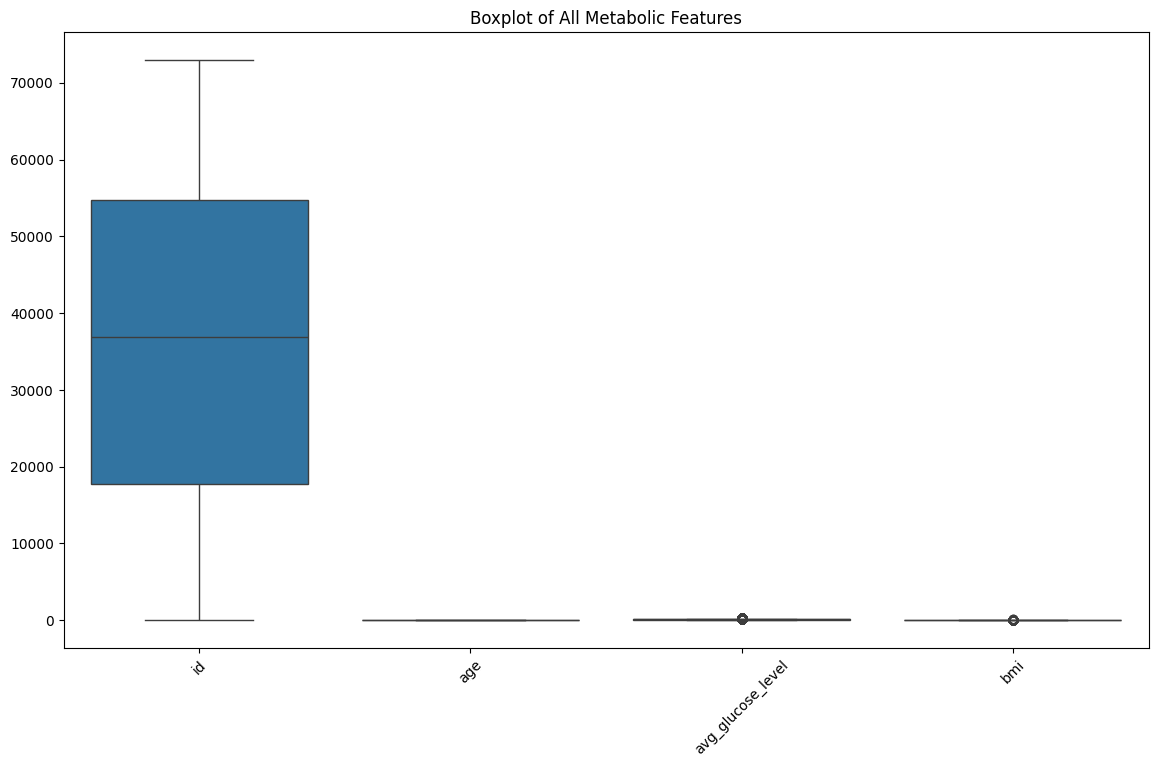

In [22]:
# step 7 : eda

# Box plot of numeric columns

numeric_cols = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(14, 8))
sns.boxplot(data=numeric_cols)
plt.xticks(rotation=45)
plt.title("Boxplot of All Metabolic Features")
plt.show()


===== Removing Outliers =====

Dataset size before removing outliers : (5110, 12)
Dataset size after removing outliers  : (4391, 12)


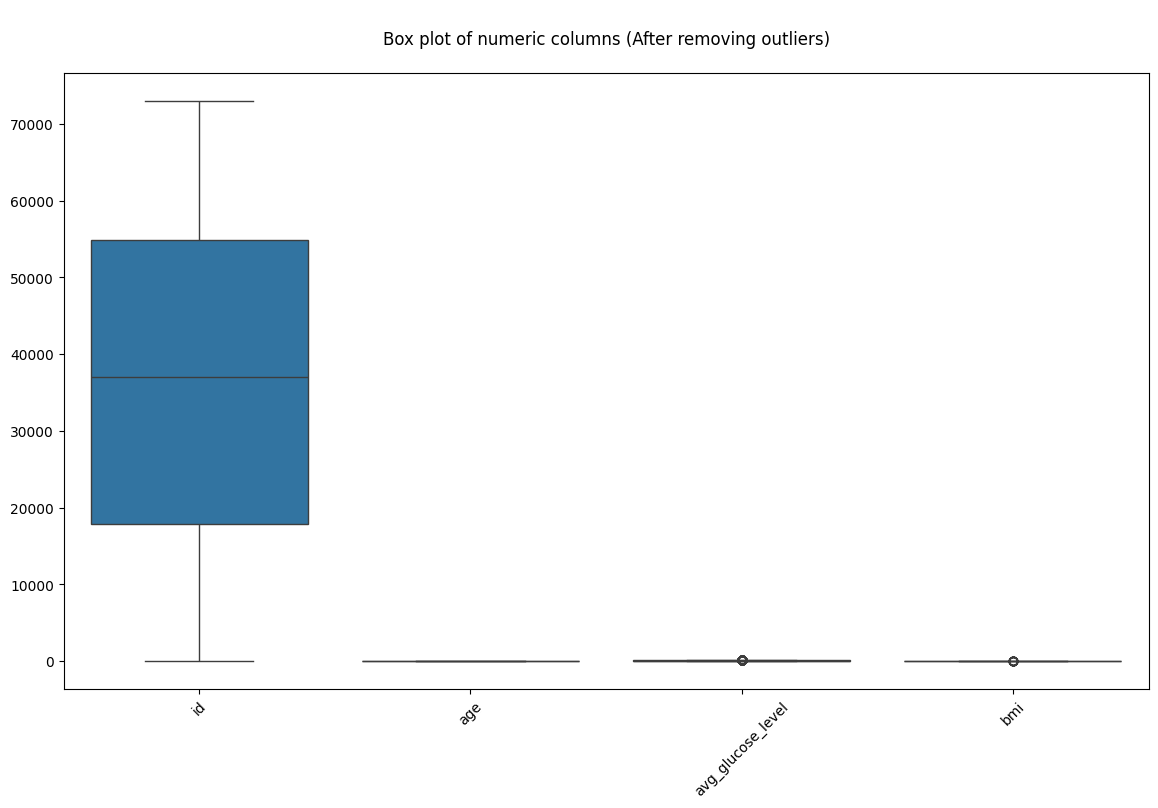

In [23]:
# Create a copy to clean
df_cleaned = df.copy()

# Remove outliers using IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]

print("\n===== Removing Outliers =====\n")
print("Dataset size before removing outliers :", df.shape)
print("Dataset size after removing outliers  :", df_cleaned.shape)

# Boxplot after removing outliers
numeric_columns = df_cleaned.select_dtypes(include=['int32', 'int64', 'float32', 'float64'])

plt.figure(figsize=(14, 8))
sns.boxplot(data=numeric_columns)
plt.xticks(rotation=45)
plt.title("\nBox plot of numeric columns (After removing outliers)\n")
plt.show()

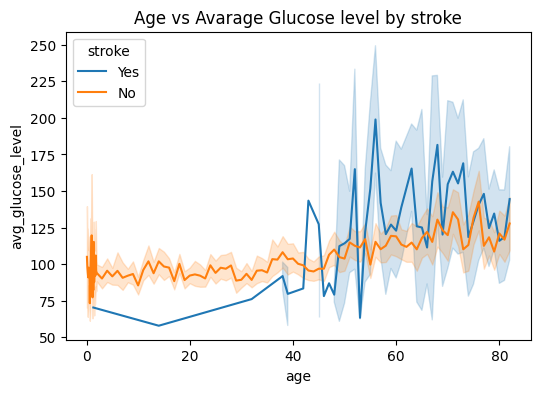

In [24]:
# Avarage Glucose Level vs Age

plt.figure(figsize=(6,4))
sns.lineplot(
    data=df,
    x='age',
    y='avg_glucose_level',
    hue='stroke'
)
plt.title('Age vs Avarage Glucose level by stroke')
plt.show()

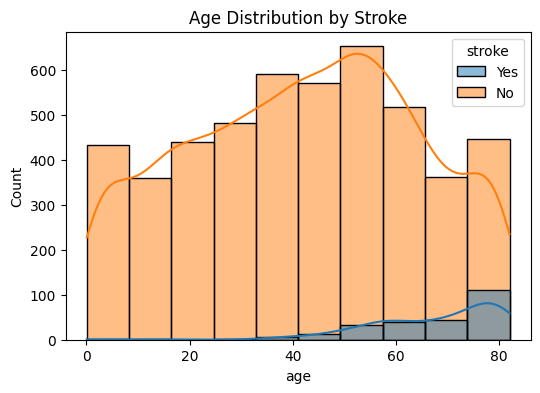

In [25]:
# Age Distribution by Stroke

plt.figure(figsize=(6,4))
sns.histplot(data=df, x='age', hue='stroke', bins=10, kde=True)
plt.title('Age Distribution by Stroke')
plt.show()


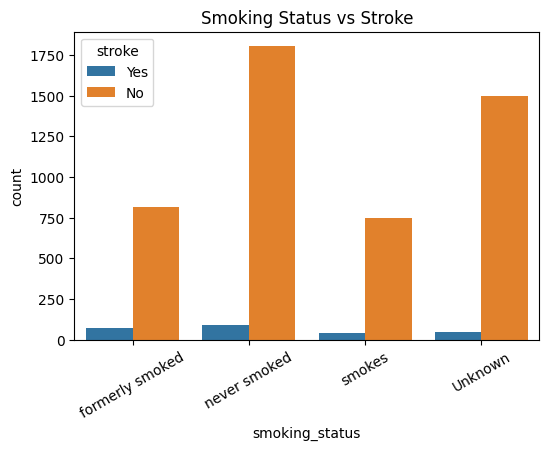

In [26]:
# Smoking Status vs Stroke

plt.figure(figsize=(6,4))
sns.countplot(x='smoking_status', hue='stroke', data=df)
plt.xticks(rotation=30)
plt.title('Smoking Status vs Stroke')
plt.show()

<Figure size 500x400 with 0 Axes>

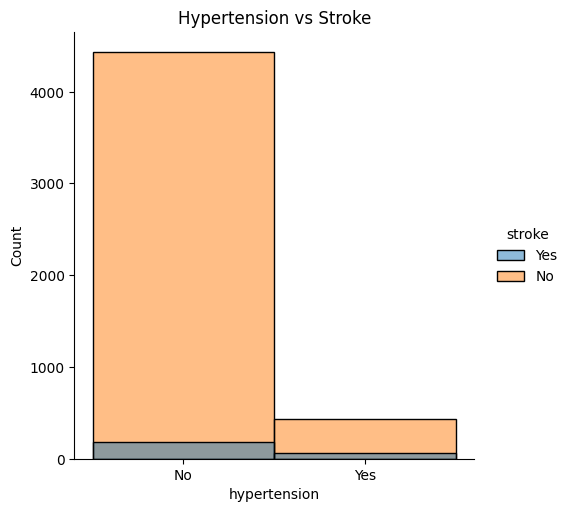

In [27]:
# Hypertension & Stroke

plt.figure(figsize=(5,4))
sns.displot(x='hypertension', hue='stroke', data=df)
plt.title('Hypertension vs Stroke')
plt.show()

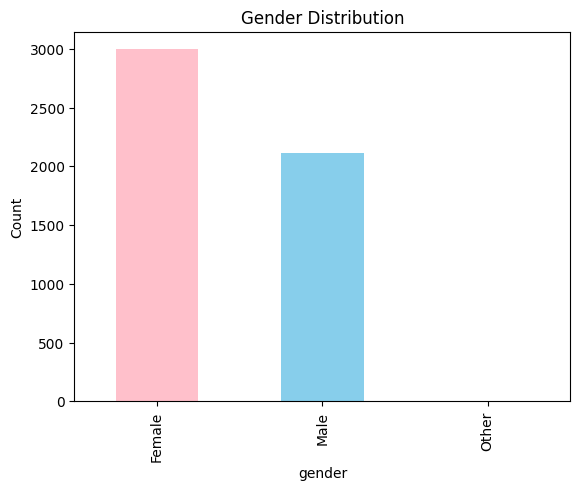

In [28]:
plt.figure()

df['gender'].value_counts().plot(
    kind='bar',
    color=['pink', 'skyblue']  
)

plt.xlabel('gender')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.show()

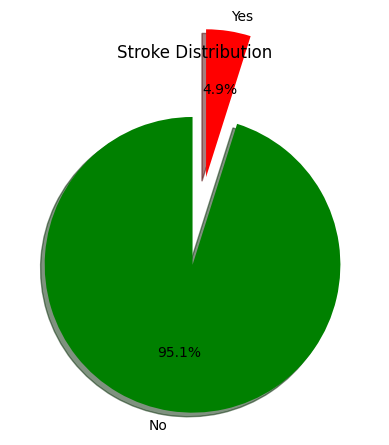

In [29]:
# Stroke Distribution

stroke_counts = df['stroke'].value_counts()
explode = [0.1, 0.5]
colors = ( "green", "red")
plt.figure()
plt.pie(
    stroke_counts,
    labels=stroke_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    colors=colors, shadow=True
)
plt.title('Stroke Distribution')
plt.show()


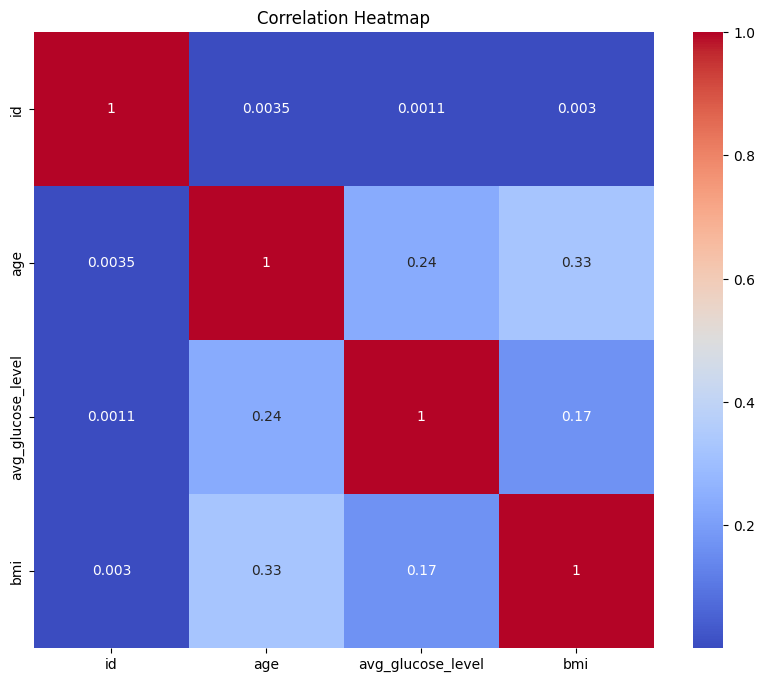

In [30]:
# Correlation Between Numerical Features

plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

In [31]:
# Step 8 : split X and y

X = df_cleaned.drop(['stroke', 'id', ], axis = 1)
y = df_cleaned['stroke']

In [32]:
# Step 9 : convert y to label encoding

le = LabelEncoder()
y = le.fit_transform(y)

In [33]:
# Step 10 : Train test split

X_train, X_test, y_train , y_test, = train_test_split(X, y,  test_size = 0.2, random_state = 42, stratify = y)

In [34]:
# Step 11 : using scaling and encode for rest features

numeric_cols = X_train.select_dtypes(include = ['int64', 'float64']).columns
category_cols =X_train.select_dtypes(include = ['object']).columns
preprocess = ColumnTransformer(
    transformers = [('scaler', StandardScaler(), numeric_cols),
                    ('onehot', OneHotEncoder(handle_unknown = 'ignore'), category_cols)
                   ],
                     remainder = 'passthrough'
                    )                   

In [35]:
# Step 12 : Train classification model

models = {
            'Logistic Regression' : LogisticRegression(C = 1.0, penalty = 'l2', max_iter = 100, random_state = 42),
            'Decision Tree Classifier' : DecisionTreeClassifier(criterion = 'gini', max_depth = 5, min_samples_split = 4, min_samples_leaf = 2),
            'Random Forest Classifier' : RandomForestClassifier(n_estimators = 100, max_depth = 5, min_samples_split = 4, min_samples_leaf = 2),
            'SVC' : SVC(C = 1.0, gamma = 'scale', random_state = 42),
            'KNN' : KNeighborsClassifier(n_neighbors = 5, weights = 'uniform', n_jobs = -1)
            
    
}
    

In [36]:
# Step 13 : Train cross validation

cv_methods = {
                'K Fold' : KFold(n_splits = 5, shuffle = True, random_state = 42),
                'Stratified K Fold' : StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42),
                'ShuffleSplit' : ShuffleSplit(n_splits = 5, test_size = 0.2, random_state = 42),
                'RepeatedKFold' :  RepeatedKFold(n_splits =5, n_repeats = 3, random_state = 42)
}

best_model = None
best_method = None
best_accuracy = 0

In [37]:
# Step 14 : Model Evaluation

for model_name, model in models.items():
    print(f"\n===== {model_name} =====")
    for method_name, method in cv_methods.items():

        pipeline = Pipeline([
            ('preprocess', preprocess),
            ('model', model)
        ])

        cv_score = cross_val_score(pipeline, X_train, y_train, cv=method).mean()

        print(f"{method_name} → Accuracy: {cv_score:.2f}")

        if cv_score > best_accuracy:
            best_accuracy = cv_score
            best_model = model_name
            best_method = method_name

print("\n========== Best Model Results ==========")
print("Best Model   :", best_model)
print("Best Method  :", best_method)
print(f"Best Accuracy:, {best_accuracy:.2f}")


===== Logistic Regression =====
K Fold → Accuracy: 0.96
Stratified K Fold → Accuracy: 0.96
ShuffleSplit → Accuracy: 0.96
RepeatedKFold → Accuracy: 0.96

===== Decision Tree Classifier =====
K Fold → Accuracy: 0.96
Stratified K Fold → Accuracy: 0.96
ShuffleSplit → Accuracy: 0.96
RepeatedKFold → Accuracy: 0.96

===== Random Forest Classifier =====
K Fold → Accuracy: 0.96
Stratified K Fold → Accuracy: 0.96
ShuffleSplit → Accuracy: 0.96
RepeatedKFold → Accuracy: 0.96

===== SVC =====
K Fold → Accuracy: 0.96
Stratified K Fold → Accuracy: 0.96
ShuffleSplit → Accuracy: 0.96
RepeatedKFold → Accuracy: 0.96

===== KNN =====
K Fold → Accuracy: 0.96
Stratified K Fold → Accuracy: 0.96
ShuffleSplit → Accuracy: 0.96
RepeatedKFold → Accuracy: 0.96

========== Best Model Results ==========
Best Model   : Logistic Regression
Best Method  : ShuffleSplit
Best Accuracy:, 0.96


In [38]:
# Step 15 : Train grid search parameters

# Using grid search cv

param_grid = {
    'Logistic Regression': {
        'model__C': [0.1, 1, 10],
        'model__max_iter': [100, 300, 500]
    },
    'Decision Tree Classifier': {
        'model__max_depth': [3, 5, 7, None],
        'model__criterion': ['gini', 'entropy']
    },
    'Random Forest Classifier': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [5, 10, None]
    },
   

    'KNN': {
        'model__n_neighbors': [3, 5, 7]
    },
    'SVC': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf']
    }
    }


best_model = None
best_score = 0
best_name = None
best_params = None

In [39]:
# Step 16 : Model evaluation grid search

for model_name, model in models.items():
    print(f"\n ===== {model_name} ===== \n")

    pipeline = Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])

    grid = GridSearchCV(
        estimator = pipeline,
        param_grid = param_grid[model_name],
        scoring = 'accuracy',
        n_jobs = -1,
        cv = 3
    )

    grid.fit(X_train, y_train)

    print("Best Params :", grid.best_params_)
    print(f"Accuracy Score : {grid.best_score_:.2f}")

    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_params = grid.best_params_
        best_model = grid.best_estimator_
        best_name = model_name

print("\n ===== Best Model Details ===== \n")
print(f"Best Model    : {best_name}")
print(f"Best Params   : {best_params}")
print(f"Best Accuracy : {best_score:.2f}")


 ===== Logistic Regression ===== 

Best Params : {'model__C': 10, 'model__max_iter': 100}
Accuracy Score : 0.96

 ===== Decision Tree Classifier ===== 

Best Params : {'model__criterion': 'gini', 'model__max_depth': 3}
Accuracy Score : 0.96

 ===== Random Forest Classifier ===== 

Best Params : {'model__max_depth': 5, 'model__n_estimators': 100}
Accuracy Score : 0.96

 ===== SVC ===== 

Best Params : {'model__C': 0.1, 'model__kernel': 'linear'}
Accuracy Score : 0.96

 ===== KNN ===== 

Best Params : {'model__n_neighbors': 5}
Accuracy Score : 0.96

 ===== Best Model Details ===== 

Best Model    : Logistic Regression
Best Params   : {'model__C': 10, 'model__max_iter': 100}
Best Accuracy : 0.96


In [40]:
# Step 17 : fit final model

# Recreate the best model pipeline

best_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', models[model_name])
])

# fit on full training data
best_pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('onehot', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
# Step 18 : Save model

joblib.dump({'pipeline' : best_pipeline,
             'label_encoder' : le},
             'Stroke_prediction.pkl')

print("Model saved successfully.....!")

Model saved successfully.....!


In [42]:
# Step 19 : Model results

y_pred = best_pipeline.predict(X_test)

print("Classification Report :\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix :\n")
print(confusion_matrix(y_test, y_pred))

Classification Report :

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       846
           1       0.00      0.00      0.00        33

    accuracy                           0.96       879
   macro avg       0.48      0.50      0.49       879
weighted avg       0.93      0.96      0.94       879

Confusion Matrix :

[[843   3]
 [ 33   0]]


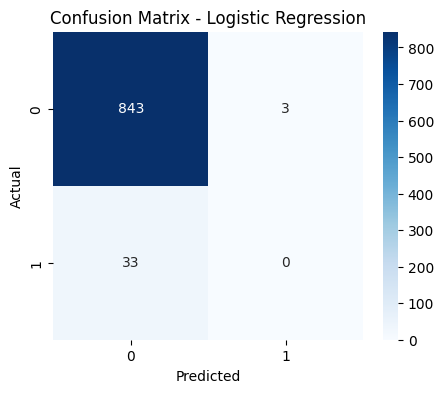

In [43]:
y_pred = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

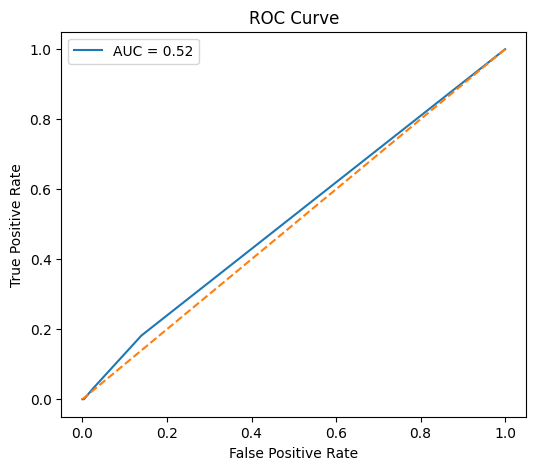


ROC-AUC Score: 0.52


In [44]:
# Predict probabilities
y_prob = best_pipeline.predict_proba(X_test)[:, 1]  # probability of positive class

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print(f"\nROC-AUC Score: {auc_score:.2f}")

In [45]:
# Train best model on full training data

best_model_obj = models[best_name]

final_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', best_model_obj)
])

final_pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('onehot', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [46]:
sample_data = pd.DataFrame([
    {
        'id': 51676,
        'gender': 'Female',
        'age': 49.0,
        'hypertension': 'Yes',
        'heart_disease': 'Yes',
        'ever_married': 'Yes',
        'work_type': 'Private',
        'Residence_type': 'Urban',
        'avg_glucose_level': 202.92,
        'bmi': 32.4000000,
        'smoking_status': 'never smoked',
    },
    {
        
        'id': 9046,
        'gender': 'Male',
        'age': 42.0,
        'hypertension': 'No',
        'heart_disease': 'No',
        'ever_married': 'Yes',
        'work_type': 'Self-employed',
        'Residence_type': 'Rural',
        'avg_glucose_level': 105.21,
        'bmi': 34.400000	,
        'smoking_status': 'smokes',

    }
])        

In [47]:
# step 20 : prediciton

predictions = best_pipeline.predict(sample_data)


print("\n========== STROKE PREDICTION ==========\n")

for i, pred in enumerate(predictions):
    label = le.inverse_transform([pred])[0]
    print(f"Patient {i+1}")
    print(f"Patient Class : {label}")
    print("-----------------------------------")


========== STROKE PREDICTION ==========

Patient 1
Patient Class : No
-----------------------------------
Patient 2
Patient Class : No
-----------------------------------


# CLUSTERING

In [48]:
# Step 1 : Import libararies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [49]:
# Step 2 : Load dataset

df = pd.read_csv("healthcare-dataset-stroke-data.csv")
print("Dataset Loaded Successfully")

# printing sample dataset

df.head()


Dataset Loaded Successfully


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [50]:
# Step 3 : Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [51]:
# Dataset Shape and size

print("Dataset Shape :" , df.shape)

print("Dataset Size :" , df.size)

Dataset Shape : (5110, 12)
Dataset Size : 61320


In [52]:
# Dataset description

df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [53]:
# Step 4 : Dataset cleaning

# Checking for duplicate values

print("Duplicate Value Count :" , df.duplicated().sum())

Duplicate Value Count : 0


In [54]:
# checking for null values 

print("Null value count before cleaning :\n", df.isnull().sum())

df.dropna(inplace = True)

print("\nNull value count after cleaning  :\n", df.isnull().sum())

Null value count before cleaning :
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Null value count after cleaning  :
 id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [55]:
# checking for null values 

print("Null value count before cleaning :\n", df.isnull().sum())

df.dropna(inplace = True)

print("\nNull value count after cleaning  :\n", df.isnull().sum())

Null value count before cleaning :
 id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Null value count after cleaning  :
 id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


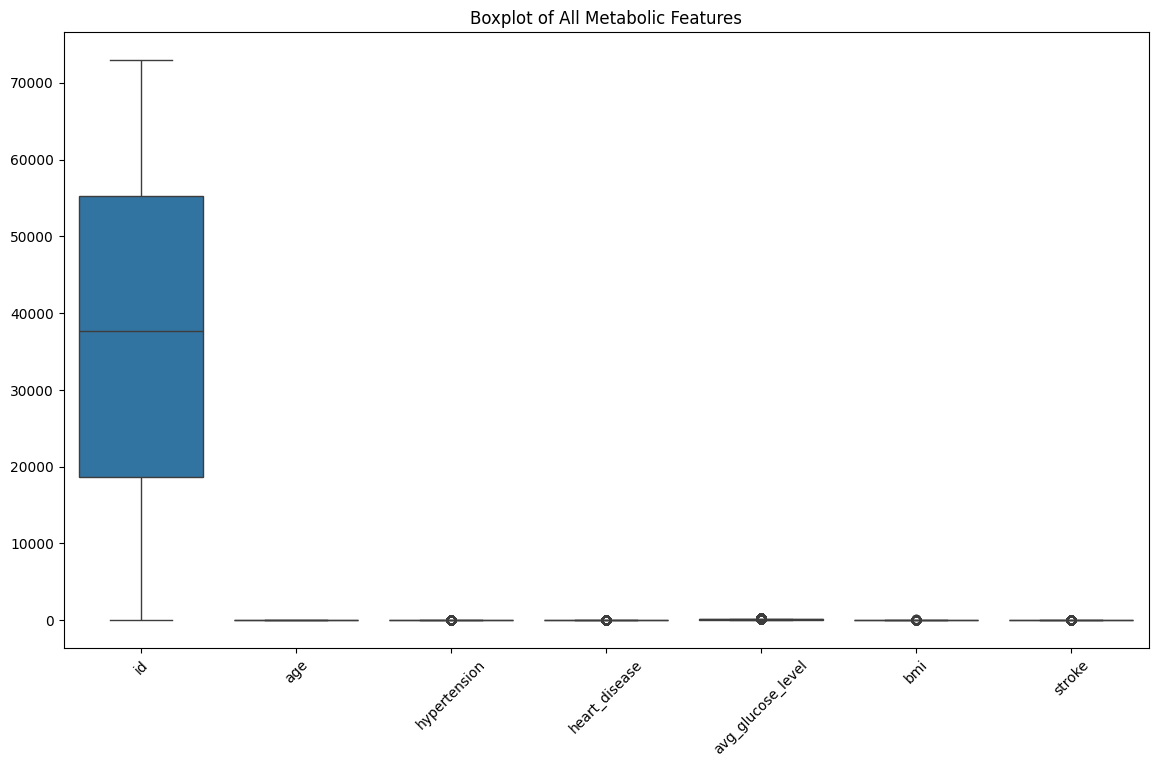

In [56]:
# Step 5 : EDA

# Box plot of numeric columns

numeric_cols = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(14, 8))
sns.boxplot(data=numeric_cols)
plt.xticks(rotation=45)
plt.title("Boxplot of All Metabolic Features")
plt.show()


===== Removing Outliers =====

Dataset size before removing outliers : (4909, 12)
Dataset size after removing outliers  : (3755, 12)


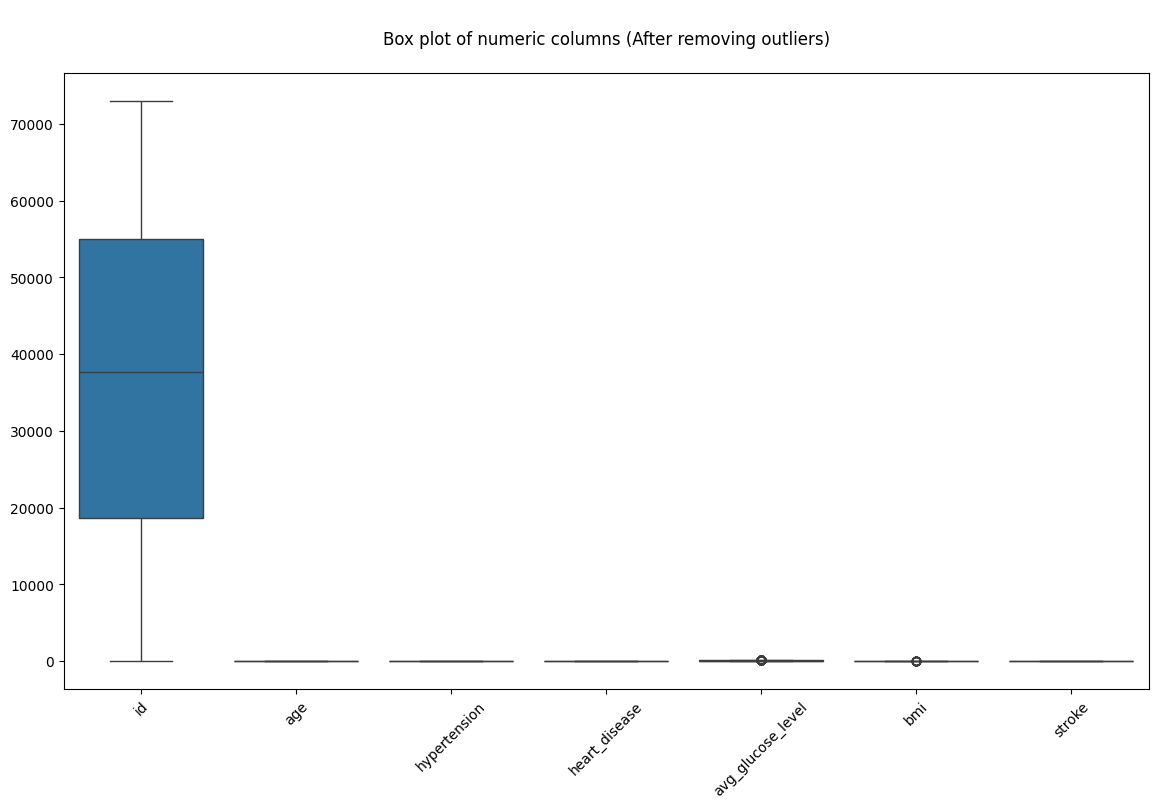

In [57]:
# Create a copy to clean
df_cleaned = df.copy()

# Remove outliers using IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]

print("\n===== Removing Outliers =====\n")
print("Dataset size before removing outliers :", df.shape)
print("Dataset size after removing outliers  :", df_cleaned.shape)

# Boxplot after removing outliers
numeric_columns = df_cleaned.select_dtypes(include=['int32', 'int64', 'float32', 'float64'])

plt.figure(figsize=(14, 8))
sns.boxplot(data=numeric_columns)
plt.xticks(rotation=45)
plt.title("\nBox plot of numeric columns (After removing outliers)\n")
plt.show()

In [58]:
# Step 6 : Selecting feature columns

features = ["age", "avg_glucose_level", "bmi"]

X = df_cleaned[features].copy()

In [59]:
# Step 7 : Preprocessing x features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [60]:
# Step 8 : Choosing number of clusters

wcss = []

for i in range(2,10):
	kmeans = KMeans(n_clusters = i)
	kmeans.fit(X_scaled)
	wcss.append(kmeans.inertia_)

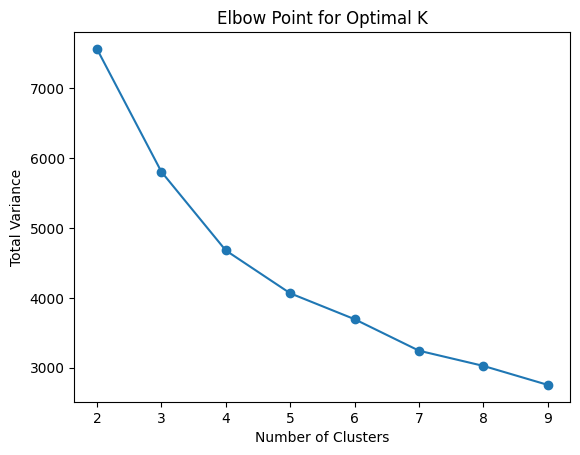

In [61]:
plt.plot(range(2,10), wcss, marker="o")
plt.title("Elbow Point for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Total Variance")
plt.show()

In [62]:
# Step 9 : Prediction

kmeans = KMeans(n_clusters = 5)

df_cleaned["Cluster"] = kmeans.fit_predict(X_scaled)

In [63]:
cluster_summary = df_cleaned.groupby("Cluster")[features].mean()
cluster_summary.head()

,age,avg_glucose_level,bmi
Cluster,,,
0,16.449778,77.967811,21.806111
1,58.704212,80.767395,26.878159
2,50.642857,123.976270,30.465079
3,39.526448,82.863111,36.097103
4,17.359478,116.623545,22.369403


In [64]:
df_cleaned["Cluster"].value_counts()

Cluster
1    1021
0     900
3     794
4     536
2     504
Name: count, dtype: int64

In [65]:
# Step 10 : PCA

pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)

df_cleaned["PCA1"], df_cleaned["PCA2"] = pca_data[:,0], pca_data[:, 1]

In [66]:
cluster_profile = df_cleaned.groupby("Cluster")[features].mean()

cluster_profile

,age,avg_glucose_level,bmi
Cluster,,,
0,16.449778,77.967811,21.806111
1,58.704212,80.767395,26.878159
2,50.642857,123.976270,30.465079
3,39.526448,82.863111,36.097103
4,17.359478,116.623545,22.369403


In [67]:
cluster_profile = cluster_profile.sort_values("avg_glucose_level", ascending=False)
cluster_profile

,age,avg_glucose_level,bmi
Cluster,,,
2,50.642857,123.976270,30.465079
4,17.359478,116.623545,22.369403
3,39.526448,82.863111,36.097103
1,58.704212,80.767395,26.878159
0,16.449778,77.967811,21.806111


In [68]:
glucose_level_names = [
    "High Glucose Level",
    "Very High Glucose Level",
    "Normal Gucose Level",
    "Low Glucose level",
    "Very Low Glucose level"
]

cluster_profile["Glucose Level"] = glucose_level_names[:len(cluster_profile)]

cluster_profile

,age,avg_glucose_level,bmi,Glucose Level
Cluster,,,,
2,50.642857,123.976270,30.465079,High Glucose Level
4,17.359478,116.623545,22.369403,Very High Glucose Level
3,39.526448,82.863111,36.097103,Normal Gucose Level
1,58.704212,80.767395,26.878159,Low Glucose level
0,16.449778,77.967811,21.806111,Very Low Glucose level


In [69]:
cluster_labels = cluster_profile["Glucose Level"].to_dict()

df_cleaned["Cluster_Name"] = df_cleaned["Cluster"].map(cluster_labels)

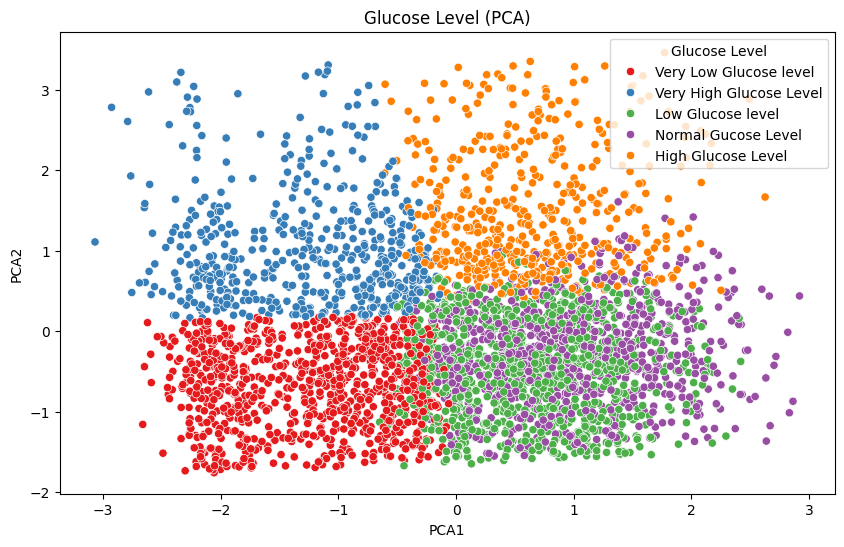

In [70]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster_Name",
    data=df_cleaned,
    palette="Set1"
)

plt.title("Glucose Level (PCA)")
plt.legend(title="Glucose Level")
plt.show()

# ARTIFICIAL NEURAL NETWORK

In [71]:
# Step 1 : Import libraries

# Import common libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Import sklearns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, auc, roc_curve, roc_auc_score
from sklearn.compose import ColumnTransformer

# Import Deep learning models

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [72]:
# Step 2 : Load dataset

df = pd.read_csv("healthcare-dataset-stroke-data.csv")
print("Dataset Loaded Successfully")

# Printing sample dataset

df.head()

Dataset Loaded Successfully


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [73]:
# Step 3 : Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [74]:
# Dataset size

print("Dataset Size :", df.size)

# Dataset Shape

print("Dataset Shape :", df.shape)

Dataset Size : 61320
Dataset Shape : (5110, 12)


In [75]:
# Dataset description

df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [76]:
# Step 4 : Dataset cleaning

# cleaning column names

print("Columns Names Before Cleaning :", df.columns)
df.columns = df.columns.str.strip().str.replace('[^A-Za-z0-9_]+', '_', regex = True).str.strip('_')
print("\nColumns Names After Cleaning :", df.columns)

Columns Names Before Cleaning : Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

Columns Names After Cleaning : Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


In [77]:
# Droping duplicated values

print("Duplicate Values Counts :", df.duplicated().sum())

Duplicate Values Counts : 0


In [78]:
# Cleaning null values

print("Null Values Before Cleaning :\n", df.isnull().sum())

# Filling category null Values with mode

category_cols = df.select_dtypes(include = 'object').columns

for col in category_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# filling numeric null values with mean

numeric_cols = df.select_dtypes(include = ['int64','float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

print("\nNull Values After Cleaning:\n", df.isnull().sum())

Null Values Before Cleaning :
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Null Values After Cleaning:
 id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


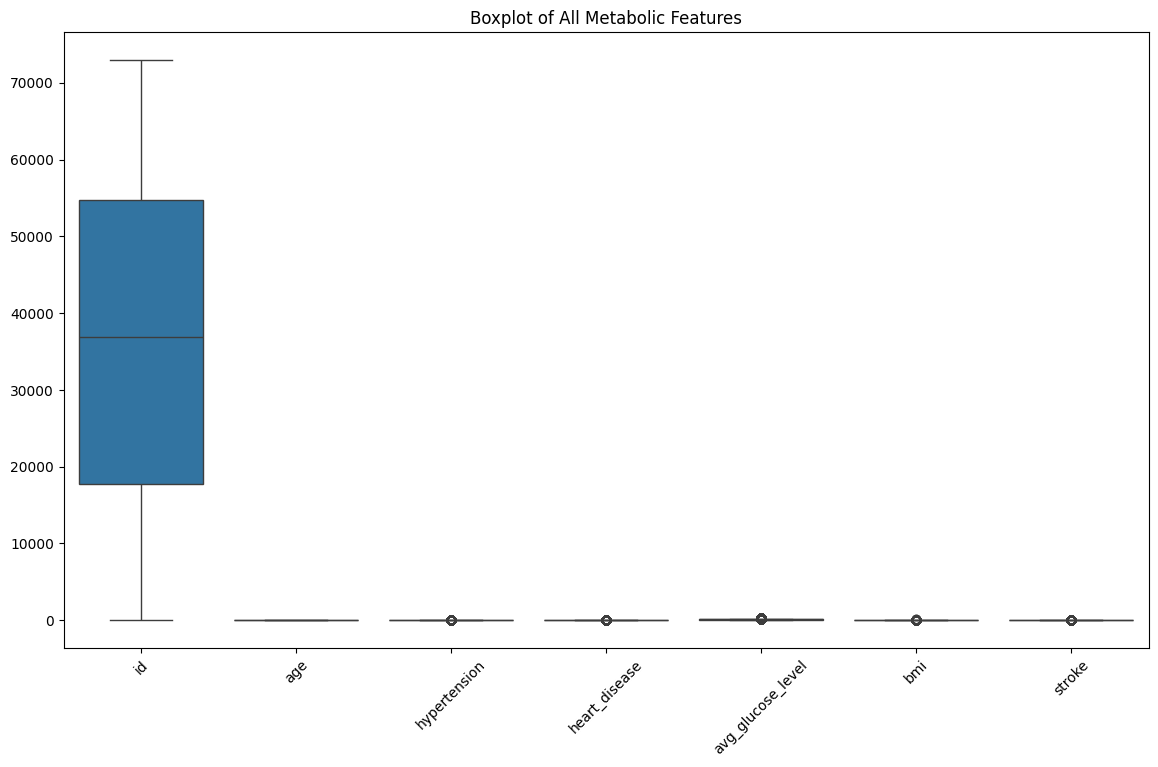

In [79]:
# Step 5 : EDA

# Box plot of numeric columns

numeric_cols = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(14, 8))
sns.boxplot(data=numeric_cols)
plt.xticks(rotation=45)
plt.title("Boxplot of All Metabolic Features")
plt.show()


===== Removing Outliers =====

Dataset size before removing outliers : (5110, 12)
Dataset size after removing outliers  : (3814, 12)


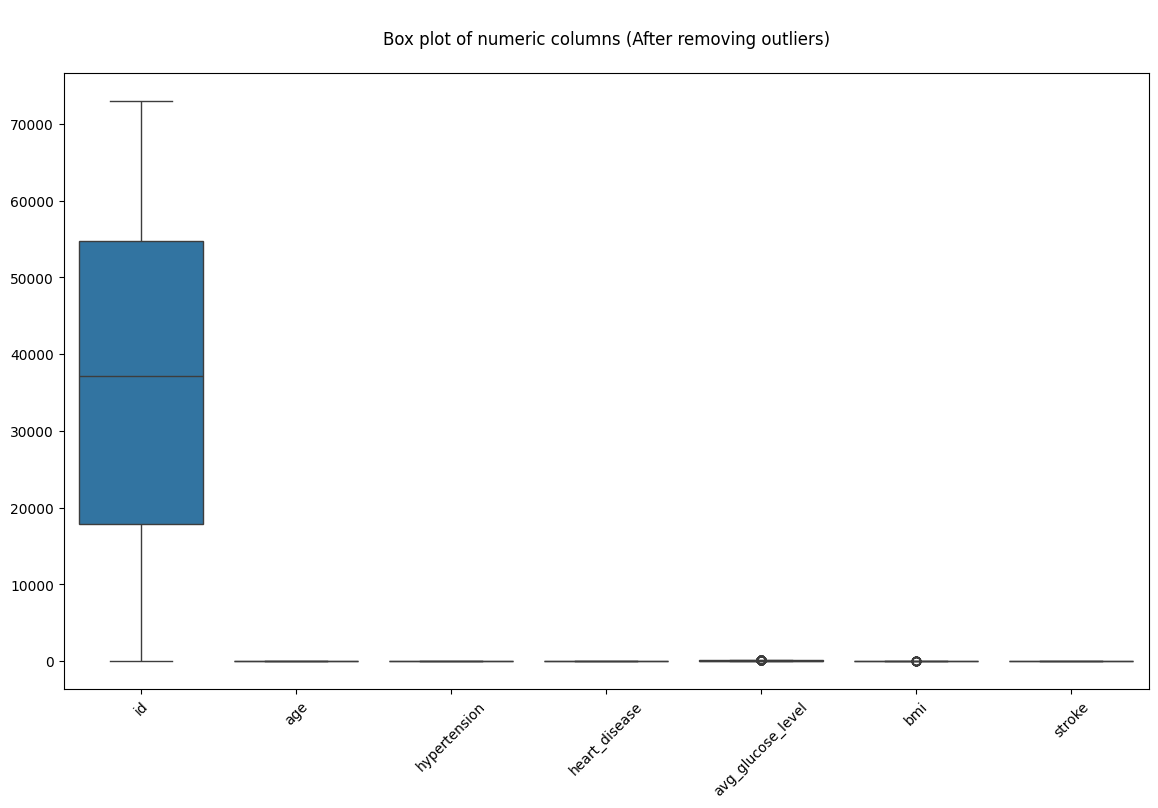

In [80]:
# Create a copy to clean
df_cleaned = df.copy()

# Remove outliers using IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]

print("\n===== Removing Outliers =====\n")
print("Dataset size before removing outliers :", df.shape)
print("Dataset size after removing outliers  :", df_cleaned.shape)

# Boxplot after removing outliers
numeric_columns = df_cleaned.select_dtypes(include=['int32', 'int64', 'float32', 'float64'])

plt.figure(figsize=(14, 8))
sns.boxplot(data=numeric_columns)
plt.xticks(rotation=45)
plt.title("\nBox plot of numeric columns (After removing outliers)\n")
plt.show()

In [81]:
# Step 6 : Split x and y

X = df.drop(['stroke'], axis = 1)
y = df['stroke']

In [82]:
# step 7 : Convert y to label encoding

le = LabelEncoder()
y = le.fit_transform(y)

In [83]:
# Step 9 : Train Test Split

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.2, random_state = 42, stratify = y)

In [84]:
# Using scaling and encode for rest features

numeric_cols = X.select_dtypes(include = ['int64', 'float64']).columns
category_cols = X.select_dtypes(include = 'object').columns
preprocess = ColumnTransformer(
    transformers = [('scaler', StandardScaler(), numeric_cols),
                    ('onehot',OneHotEncoder(handle_unknown = 'ignore'), category_cols),
                   ],
                     remainder = 'passthrough'
)
                               

In [85]:
# Step 10 : Fitting X_train and X_test

X_train_preprocess = preprocess.fit_transform(X_train)
X_test_preprocess = preprocess.transform(X_test)

In [86]:
# Step 11 : Model Building

input_dim = X_train_preprocess.shape[1]
model = Sequential([
    Dense(128, activation = 'relu', input_shape = (input_dim, )),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation = 'relu'),

    Dense(1, activation = 'sigmoid')

    ])

model.summary()         

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,081 (55.00 KB)

 Trainable params: 13,697 (53.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [87]:
# Model compiling
model.compile(
    optimizer = Adam(learning_rate = 0.0001),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [88]:
# Early stoping(for reducing overfiting)

early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True

) 

In [89]:
# Fitting Model

history = model.fit(
    X_train_preprocess,
    y_train,
    epochs = 100,
    batch_size = 32,
    callbacks = [early_stop],
    verbose = 1,
    validation_split = 0.2

)
    

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3798 - loss: 0.9736 - val_accuracy: 0.1687 - val_loss: 0.8502
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5544 - loss: 0.7218 - val_accuracy: 0.4205 - val_loss: 0.7245
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7226 - loss: 0.5489 - val_accuracy: 0.8081 - val_loss: 0.5041
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8251 - loss: 0.4309 - val_accuracy: 0.9315 - val_loss: 0.3623
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8930 - loss: 0.3501 - val_accuracy: 0.9413 - val_loss: 0.2905
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9211 - loss: 0.3039 - val_accuracy: 0.9425 - val_loss: 0.2533
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9297 - loss: 0.2725 - val_accuracy: 0.9425 - val_loss: 0.2334
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9382 - loss: 0.2544 - val_accu

In [90]:
# Final Step Model Evaluvation

y_pred_prob = model.predict(X_test_preprocess)

y_pred = (y_pred_prob > 0.5 ).astype(int)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy Score :{accuracy:.2f}")

classification = classification_report(y_test, y_pred)

print(f"\nClassification Report :\n {classification}")

confusion = confusion_matrix(y_test, y_pred)

print(f"Confusion Matrix :\n {confusion}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Accuracy Score :0.95

Classification Report :
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

Confusion Matrix :
 [[972   0]
 [ 50   0]]
